LOAN DEFAULT PREDICTION - COMPLETE PIPELINE

GPU Available: True
GPU: Tesla T4
✓ Setup complete - Using GPU

STAGE 1: DATA LOADING
✓ Loaded: (32581, 12)

First 5 rows:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27        

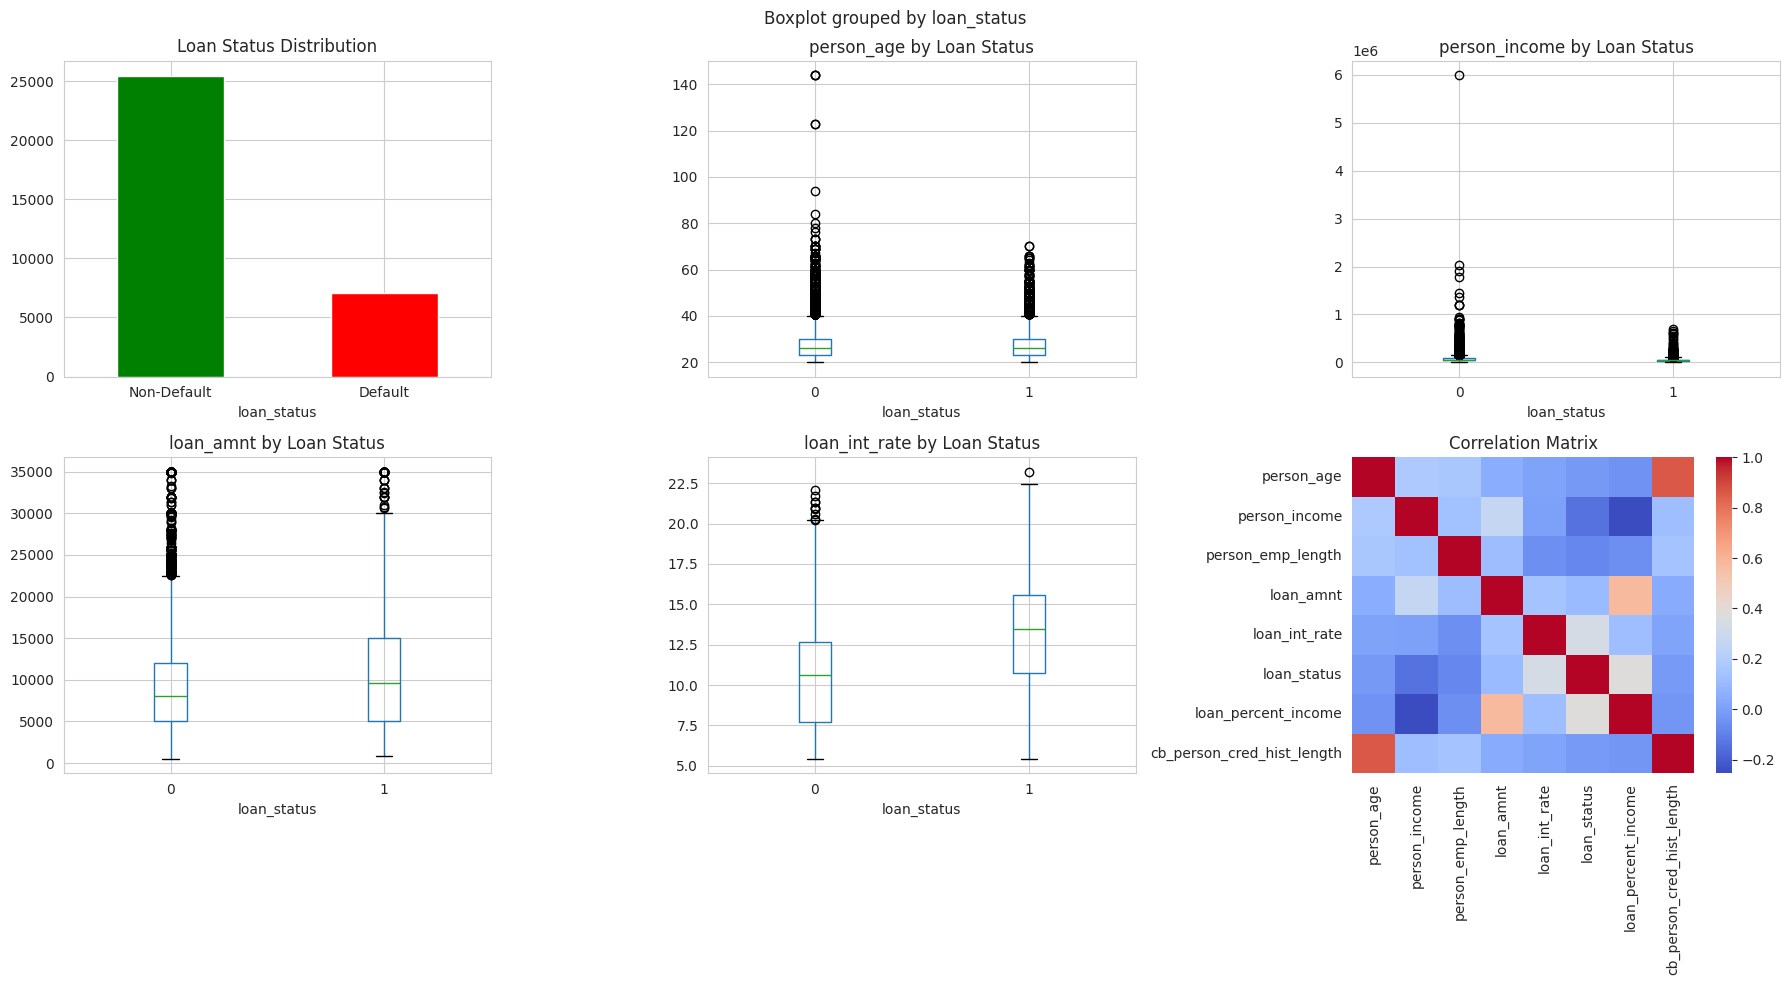


STAGE 3: PREPROCESSING
Shape after dropping nulls: (28638, 12)
Numerical: 7, Categorical: 4

STAGE 4: FEATURE ENGINEERING
[Label Encoding]
  cb_person_default_on_file: ['N', 'Y']

[One-Hot Encoding]

[Scaling]
✓ Final shape: (28638, 23)

STAGE 5: TRAIN-TEST SPLIT
Training: 22,910 samples
Test: 5,728 samples
Features: 22

STAGE 6: MODEL TRAINING

[BASELINE MODELS]

[Logistic Regression]
  CV F1: 0.6526, Test F1: 0.6206, Time: 2.4s

[Naive Bayes]
  CV F1: 0.5063, Test F1: 0.5423, Time: 0.2s

[Random Forest]
  CV F1: 0.8237, Test F1: 0.8084, Time: 9.9s

[APPLYING SMOTE-ENN]
Resampled: 29,080 samples (55.7% default)

[MAIN MODELS - GPU ACCELERATED]

[XGBoost]
  CV F1: 0.9732, Test F1: 0.7729, Time: 1.8s

[LightGBM]


[I 2025-12-06 08:09:14,845] A new study created in memory with name: no-name-211c2926-89a7-4bca-bfd3-7a36492bd543


  CV F1: 0.9683, Test F1: 0.7639, Time: 11.0s

[HYPERPARAMETER TUNING]
Tuning XGBoost (20 trials)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-12-06 08:09:15,526] Trial 0 finished with value: 0.9064635340100086 and parameters: {'max_depth': 6, 'learning_rate': 0.012472702197554942, 'n_estimators': 59}. Best is trial 0 with value: 0.9064635340100086.
[I 2025-12-06 08:09:16,618] Trial 1 finished with value: 0.9401375805750017 and parameters: {'max_depth': 7, 'learning_rate': 0.03403893059026612, 'n_estimators': 145}. Best is trial 1 with value: 0.9401375805750017.
[I 2025-12-06 08:09:17,413] Trial 2 finished with value: 0.9193603554420262 and parameters: {'max_depth': 6, 'learning_rate': 0.028590139518525143, 'n_estimators': 119}. Best is trial 1 with value: 0.9401375805750017.
[I 2025-12-06 08:09:18,192] Trial 3 finished with value: 0.9529748359665131 and parameters: {'max_depth': 7, 'learning_rate': 0.07478126671188473, 'n_estimators': 100}. Best is trial 3 with value: 0.9529748359665131.
[I 2025-12-06 08:09:18,671] Trial 4 finished with value: 0.9292316366842567 and parameters: {'max_depth': 3, 'learning_rate': 0.102

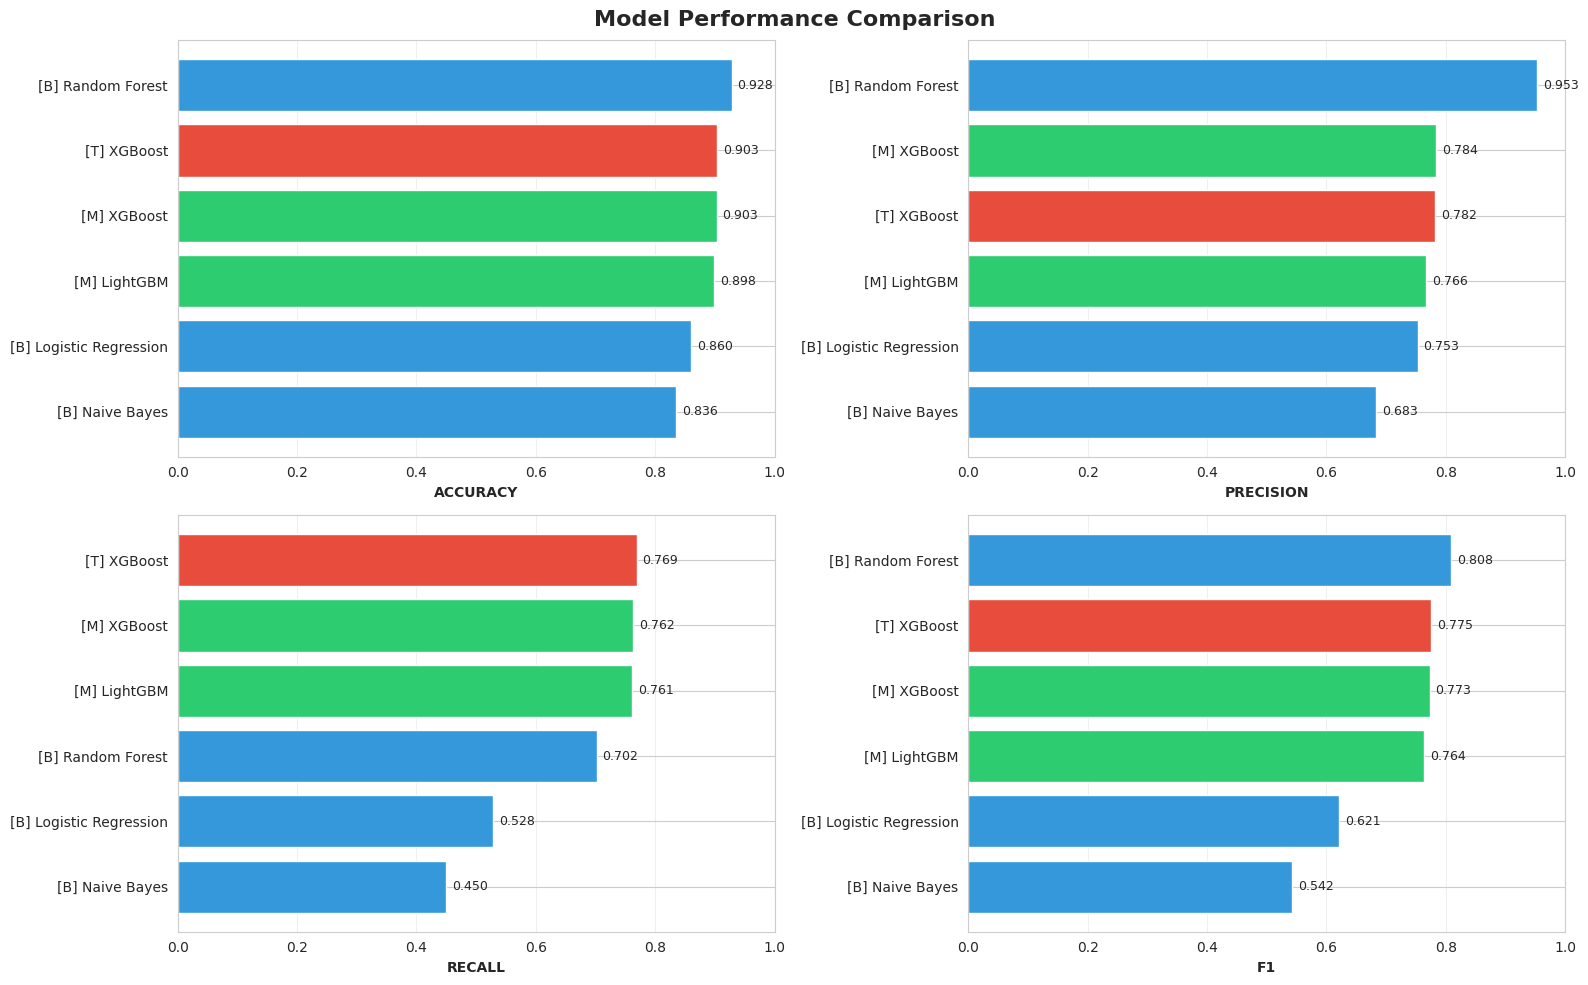

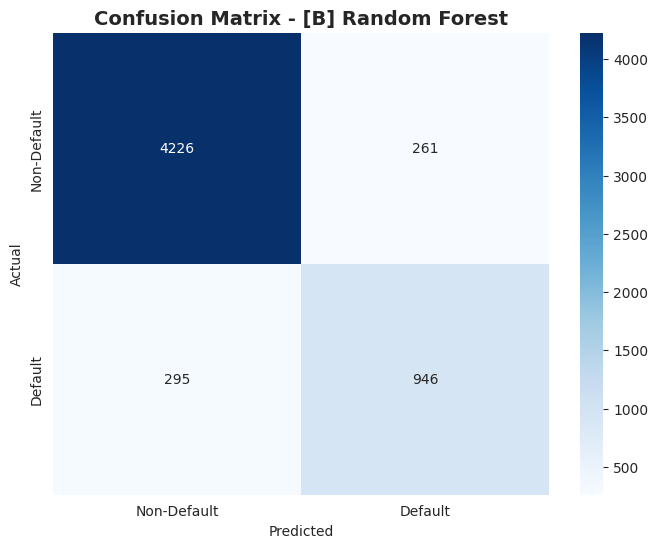


✓ PIPELINE COMPLETE!

Best Model: [B] Random Forest
Best F1-Score: 0.8084

GPU Acceleration: ENABLED


In [ ]:
"""
Complete Loan Default Prediction Pipeline
Adapted for Google Colab with GPU acceleration

Dataset Features:
- person_age, person_income, person_home_ownership
- person_emp_length, loan_intent, loan_grade
- loan_amnt, loan_int_rate, loan_status (TARGET: 0=non-default, 1=default)
- loan_percent_income, cb_person_default_on_file
- cb_preson_cred_hist_length

Instructions:
1. Upload this notebook to Google Colab
2. Runtime -> Change runtime type -> GPU (T4 recommended)
3. Run all cells
4. Upload your CSV when prompted
"""

# ============================================================================
# SETUP & INSTALLATION
# ============================================================================
print("="*80)
print("LOAN DEFAULT PREDICTION - COMPLETE PIPELINE")
print("="*80)

# Check GPU
import torch
print(f"\nGPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Install packages
!pip install -q xgboost lightgbm optuna imbalanced-learn

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from collections import defaultdict
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
import xgboost as xgb
import lightgbm as lgb
import optuna
from imblearn.combine import SMOTEENN

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# Config
RANDOM_SEED = 42
TEST_SIZE = 0.2
N_FOLDS = 5
USE_GPU = torch.cuda.is_available()
np.random.seed(RANDOM_SEED)

print(f"✓ Setup complete - Using {'GPU' if USE_GPU else 'CPU'}")

# ============================================================================
# DATA LOADING
# ============================================================================
print("\n" + "="*80)
print("STAGE 1: DATA LOADING")
print("="*80)


filename = "credit_risk_dataset.csv"
df = pd.read_csv(filename)

print(f"✓ Loaded: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumns: {df.columns.tolist()}")

# ============================================================================
# EDA
# ============================================================================
print("\n" + "="*80)
print("STAGE 2: EXPLORATORY DATA ANALYSIS")
print("="*80)

target_col = 'loan_status'

# Missing values
print("\n[Missing Values]")
missing = df.isnull().sum()
print("✓ No missing values" if missing.sum() == 0 else f"Missing: {missing[missing > 0]}")

# Target distribution
print("\n[Target Distribution]")
target_dist = df[target_col].value_counts().sort_index()
for status, count in target_dist.items():
    pct = count/len(df)*100
    print(f"  {status} ({'Non-Default' if status==0 else 'Default'}): {count:,} ({pct:.1f}%)")
print(f"  Imbalance Ratio: {target_dist.max()/target_dist.min():.2f}:1")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA - Loan Default Prediction', fontsize=16, fontweight='bold')

# Plot 1: Target
target_dist.plot(kind='bar', ax=axes[0,0], color=['green','red'])
axes[0,0].set_title('Loan Status Distribution')
axes[0,0].set_xticklabels(['Non-Default','Default'], rotation=0)

# Plot 2-5: Box plots
for idx, col in enumerate(['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']):
    ax = axes[(idx+1)//3, (idx+1)%3]
    df.boxplot(column=col, by=target_col, ax=ax)
    ax.set_title(f'{col} by Loan Status')

# Plot 6: Correlation
ax = axes[1,2]
num_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[num_cols].corr(), annot=False, cmap='coolwarm', ax=ax)
ax.set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

# ============================================================================
# PREPROCESSING
# ============================================================================
print("\n" + "="*80)
print("STAGE 3: PREPROCESSING")
print("="*80)

df_processed = df.copy()
df_processed = df_processed.dropna()
print(f"Shape after dropping nulls: {df_processed.shape}")

num_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
if target_col in num_cols:
    num_cols.remove(target_col)
cat_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical: {len(num_cols)}, Categorical: {len(cat_cols)}")

# ============================================================================
# FEATURE ENGINEERING
# ============================================================================
print("\n" + "="*80)
print("STAGE 4: FEATURE ENGINEERING")
print("="*80)

df_engineered = df_processed.copy()

# Label encoding
print("[Label Encoding]")
for col in cat_cols:
    if df_engineered[col].nunique() == 2:
        le = LabelEncoder()
        df_engineered[col] = le.fit_transform(df_engineered[col])
        print(f"  {col}: {list(le.classes_)}")

# One-hot encoding
print("\n[One-Hot Encoding]")
multi_cat = [c for c in cat_cols if df_engineered[c].nunique() > 2]
if multi_cat:
    df_engineered = pd.get_dummies(df_engineered, columns=multi_cat, drop_first=True)

# Scaling
print("\n[Scaling]")
scaler = StandardScaler()
num_to_scale = [c for c in df_engineered.columns if c in num_cols]
df_engineered[num_to_scale] = scaler.fit_transform(df_engineered[num_to_scale])

print(f"✓ Final shape: {df_engineered.shape}")

# ============================================================================
# TRAIN-TEST SPLIT
# ============================================================================
print("\n" + "="*80)
print("STAGE 5: TRAIN-TEST SPLIT")
print("="*80)

X = df_engineered.drop(columns=[target_col])
y = df_engineered[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_SEED
)

print(f"Training: {X_train.shape[0]:,} samples")
print(f"Test: {X_test.shape[0]:,} samples")
print(f"Features: {X_train.shape[1]}")

# ============================================================================
# MODEL TRAINING
# ============================================================================
print("\n" + "="*80)
print("STAGE 6: MODEL TRAINING")
print("="*80)

results = {'baseline': {}, 'main': {}}

def train_cv(model, name, X, y, n_folds=5):
    """Train with CV"""
    print(f"\n[{name}]")
    start = time.time()

    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_SEED)
    cv_scores = defaultdict(list)

    for train_idx, val_idx in skf.split(X, y):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        y_pred = model.predict(X.iloc[val_idx])
        y_proba = model.predict_proba(X.iloc[val_idx])[:,1] if hasattr(model,'predict_proba') else None

        cv_scores['f1'].append(f1_score(y.iloc[val_idx], y_pred))
        if y_proba is not None:
            cv_scores['roc_auc'].append(roc_auc_score(y.iloc[val_idx], y_proba))

    model.fit(X, y)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model,'predict_proba') else None

    test_metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None else 0
    }

    print(f"  CV F1: {np.mean(cv_scores['f1']):.4f}, Test F1: {test_metrics['f1']:.4f}, Time: {time.time()-start:.1f}s")
    return {'model': model, 'test_metrics': test_metrics}

# Baseline models
print("\n[BASELINE MODELS]")
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
}

for name, model in models.items():
    results['baseline'][name] = train_cv(model, name, X_train, y_train)

# SMOTE-ENN
print("\n[APPLYING SMOTE-ENN]")
smoteenn = SMOTEENN(random_state=RANDOM_SEED)
X_res, y_res = smoteenn.fit_resample(X_train, y_train)
print(f"Resampled: {X_res.shape[0]:,} samples ({sum(y_res==1)/len(y_res)*100:.1f}% default)")

# Main models with GPU
print("\n[MAIN MODELS - GPU ACCELERATED]")

xgb_params = {'random_state': RANDOM_SEED, 'eval_metric': 'logloss', 'use_label_encoder': False}
if USE_GPU:
    xgb_params.update({'tree_method': 'hist', 'device': 'cuda'})
results['main']['XGBoost'] = train_cv(xgb.XGBClassifier(**xgb_params), 'XGBoost', X_res, y_res)

lgb_params = {'random_state': RANDOM_SEED, 'verbose': -1}
if USE_GPU:
    lgb_params['device'] = 'gpu'
results['main']['LightGBM'] = .LGBMCtrain_cv(lgblassifier(**lgb_params), 'LightGBM', X_res, y_res)

# Hyperparameter tuning
print("\n[HYPERPARAMETER TUNING]")

def tune_xgb(X, y, n_trials=20):
    print(f"Tuning XGBoost ({n_trials} trials)...")

    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 50, 200),
            'random_state': RANDOM_SEED,
            'eval_metric': 'logloss',
            'use_label_encoder': False
        }
        if USE_GPU:
            params.update({'tree_method': 'hist', 'device': 'cuda'})

        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
        scores = []
        for train_idx, val_idx in skf.split(X, y):
            model = xgb.XGBClassifier(**params)
            model.fit(X.iloc[train_idx], y.iloc[train_idx], verbose=False)
            scores.append(f1_score(y.iloc[val_idx], model.predict(X.iloc[val_idx])))
        return np.mean(scores)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params = study.best_params.copy()
    best_params.update({'random_state': RANDOM_SEED, 'eval_metric': 'logloss', 'use_label_encoder': False})
    if USE_GPU:
        best_params.update({'tree_method': 'hist', 'device': 'cuda'})

    return train_cv(xgb.XGBClassifier(**best_params), 'XGBoost (Tuned)', X, y)

results['main']['XGBoost_tuned'] = tune_xgb(X_res, y_res, n_trials=20)

# ============================================================================
# RESULTS
# ============================================================================
print("\n" + "="*80)
print("STAGE 7: RESULTS COMPARISON")
print("="*80)

# Create results table
data = []
for name, res in results['baseline'].items():
    m = res['test_metrics']
    data.append({'Model': f'[B] {name}', 'Category': 'Baseline', **m})

for name, res in results['main'].items():
    m = res['test_metrics']
    cat = 'Tuned' if 'tuned' in name else 'Main'
    data.append({'Model': f'[{cat[0]}] {name.replace("_tuned","")}', 'Category': cat, **m})

df_results = pd.DataFrame(data)

print("\nMODEL PERFORMANCE (Test Set):")
print(df_results.to_string(index=False, float_format='%.4f'))

print("\n" + "─"*80)
print("BEST PERFORMERS:")
for metric in ['f1', 'recall', 'precision', 'roc_auc']:
    best = df_results.loc[df_results[metric].idxmax()]
    print(f"  Best {metric.upper()}: {best['Model']} ({best[metric]:.4f})")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

colors = {'Baseline': '#3498db', 'Main': '#2ecc71', 'Tuned': '#e74c3c'}

for idx, metric in enumerate(['accuracy', 'precision', 'recall', 'f1']):
    ax = axes[idx//2, idx%2]
    df_sorted = df_results.sort_values(metric)

    bars = ax.barh(df_sorted['Model'], df_sorted[metric],
                   color=[colors[c] for c in df_sorted['Category']])

    ax.set_xlabel(metric.upper(), fontweight='bold')
    ax.set_xlim(0, 1.0)
    ax.grid(axis='x', alpha=0.3)

    for i, (model, val) in enumerate(zip(df_sorted['Model'], df_sorted[metric])):
        ax.text(val+0.01, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Confusion matrix for best model
best_model_name = df_results.loc[df_results['f1'].idxmax(), 'Model']
best_model_key = 'XGBoost_tuned' if 'Tuned' in best_model_name else 'XGBoost'
best_model = results['main'][best_model_key]['model']

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticklabels(['Non-Default', 'Default'])
ax.set_yticklabels(['Non-Default', 'Default'])
plt.show()

print("\n" + "="*80)
print("✓ PIPELINE COMPLETE!")
print("="*80)
print(f"\nBest Model: {best_model_name}")
print(f"Best F1-Score: {df_results['f1'].max():.4f}")
print(f"\nGPU Acceleration: {'ENABLED' if USE_GPU else 'DISABLED'}")
print("="*80)

In [ ]:
!pip install imbalanced-learn lightgbm scikit-learn pandas numpy matplotlib seaborn joblib

In [ ]:

import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, accuracy_score,
    precision_score, roc_curve, classification_report, confusion_matrix
)
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import joblib

In [ ]:
TARGET = 'loan_status'
DATA_CSV = "credit_risk_dataset.csv"
RANDOM_STATE = 42

def ks_statistic(y_true, y_proba):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return float(np.max(np.abs(tpr - fpr)))


def load_data():
    print('Loading from', DATA_CSV)
    return pd.read_csv(DATA_CSV)

In [ ]:
def preprocess(df, target_col):
    df = df.copy()

    # Separate target
    y = df[target_col]
    X = df.drop(columns=[target_col])

    # Identify categorical columns
    cat_cols = list(X.select_dtypes(include=['object', 'category']).columns)

    # treat low-cardinality integer columns as categorical (<=20 unique)
    for c in X.select_dtypes(include=['int32', 'int64']):
        if X[c].nunique() <= 20:
            cat_cols.append(c)
    cat_cols = sorted(set(cat_cols))
    num_cols = [c for c in X.columns if c not in cat_cols]

    # Fill missing
    for c in num_cols:
        X[c] = X[c].fillna(X[c].median())
    for c in cat_cols:
        X[c] = X[c].fillna(X[c].mode().iloc[0])

    # Encode categoricals
    encoders = {}
    X_enc = X.copy()
    for c in cat_cols:
        le = LabelEncoder()
        X_enc[c] = le.fit_transform(X_enc[c].astype(str))
        encoders[c] = le

    # Scale numeric
    scaler = StandardScaler()
    X_enc[num_cols] = scaler.fit_transform(X_enc[num_cols])

    meta = {
        'cat_cols': cat_cols,
        'num_cols': num_cols,
        'encoders': encoders,
        'scaler': scaler
    }

    return X_enc, y.reset_index(drop=True), meta

In [ ]:
def run_pipeline(target_col=TARGET, random_state=RANDOM_STATE):
    df = load_data()
    print("Loaded data shape", df.shape)

    X_enc, y, meta = preprocess(df, target_col)
    X_enc = X_enc.reset_index(drop=True)
    print(meta)
    processed = pd.concat([X_enc, y.rename("target")], axis=1)

    # Train/test split (stratified)
    X_train, X_test = train_test_split(
        processed, test_size=0.3, stratify=processed['target'], random_state=random_state
    )

    # Separate features/target
    X_train_final = X_train.drop(columns=['target'])
    y_train_final = X_train['target']

    print("Before SMOTE:", X_train_final.shape, "Minority =", sum(y_train_final == 1))

    # Apply SMOTE
    sm = SMOTE(sampling_strategy="auto", random_state=random_state)
    X_train_final, y_train_final = sm.fit_resample(X_train_final, y_train_final)

    print("After SMOTE:", X_train_final.shape, "Minority =", sum(y_train_final == 1))

    X_test_final = X_test.drop(columns=['target'])
    y_test_final = X_test['target']

    # Train LightGBM
    lgb_train = lgb.Dataset(X_train_final, label=y_train_final)
    lgb_valid = lgb.Dataset(X_test_final, label=y_test_final, reference=lgb_train)

    params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting': 'gbdt',

    # ====== parameters from your table ======
    'learning_rate': 0.1,
    'max_depth': 4,
    'max_leaves': 55,
    'min_child_weight': 5,
    'bagging_fraction': 0.9,
    'feature_fraction': 0.9,
    'lambda_l1': 1e-5,     # L1 regularization
    'lambda_l2': 100,      # L2 regularization
    # ========================================

    'seed': random_state,
    'verbosity': -1
  }


    print("Training LightGBM...")
    bst = lgb.train(
        params,
        lgb_train,
        num_boost_round=1000,
        valid_sets=[lgb_train, lgb_valid],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=50)
        ]
    )

    # Predict
    y_proba = bst.predict(X_test_final, num_iteration=bst.best_iteration)
    y_pred = (y_proba >= 0.5).astype(int)

    # Metrics
    auc = roc_auc_score(y_test_final, y_proba)
    f1 = f1_score(y_test_final, y_pred)
    recall = recall_score(y_test_final, y_pred)
    acc = accuracy_score(y_test_final, y_pred)
    prec = precision_score(y_test_final, y_pred)
    ks = ks_statistic(y_test_final, y_proba)

    print("\nEvaluation on test set:")
    print(f"AUC: {auc:.4f}  KS: {ks:.4f}")
    print(f"Accuracy: {acc:.4f}  F1: {f1:.4f}  Recall: {recall:.4f}  Precision: {prec:.4f}")

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test_final, y_pred))

    print("\nClassification report:")
    print(classification_report(y_test_final, y_pred))

    joblib.dump(bst, "lightgbm_credit_bst.joblib")
    print("Saved model to lightgbm_credit_bst.joblib")

    return {
        'model': bst,
        'auc': auc,
        'ks': ks,
        'y_test': y_test_final,
        'y_proba': y_proba,
        'X_test': X_test_final
    }


# ===============================
# 4) RUN PIPELINE
# ===============================
results = run_pipeline()

Loading from credit_risk_dataset.csv
Loaded data shape (32581, 12)
{'cat_cols': ['cb_person_default_on_file', 'loan_grade', 'loan_intent', 'person_home_ownership'], 'num_cols': ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'], 'encoders': {'cb_person_default_on_file': LabelEncoder(), 'loan_grade': LabelEncoder(), 'loan_intent': LabelEncoder(), 'person_home_ownership': LabelEncoder()}, 'scaler': StandardScaler()}
Before SMOTE: (22806, 11) Minority = 4975
After SMOTE: (35662, 11) Minority = 17831
Training LightGBM...
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.942373	valid_1's auc: 0.915401
[100]	training's auc: 0.966482	valid_1's auc: 0.923225
[150]	training's auc: 0.973276	valid_1's auc: 0.927512
[200]	training's auc: 0.976277	valid_1's auc: 0.929156
[250]	training's auc: 0.978552	valid_1's auc: 0.931524
[300]	training's auc: 0.979873	valid_1's auc: 0.932647
[3

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer

def run_pipeline2(target_col=TARGET, random_state=RANDOM_STATE):

    # Load and preprocess data
    df = load_data()
    print("Loaded data shape", df.shape)

    X_enc, y, meta = preprocess(df, target_col)
    X_enc = X_enc.reset_index(drop=True)
    y = y.reset_index(drop=True)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_enc, y, test_size=0.3, stratify=y, random_state=random_state
    )

    print("Train size:", X_train.shape, "Test size:", X_test.shape)

    # -----------------------------
    # 1️⃣ PIPELINE:  SMOTE → LightGBM
    # -----------------------------
    lgb_model = lgb.LGBMClassifier(
        objective="binary",
        metric="auc",
        boosting_type="gbdt",
        verbosity=-1,
        random_state=random_state
    )

    pipeline = Pipeline(steps=[
        ('smote', SMOTE(random_state=random_state)),
        ('model', lgb_model)
    ])

    # -----------------------------
    # 2️⃣ PARAMETER SEARCH SPACE
    # -----------------------------
    param_grid = {
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 4, 5, 6],
        'model__max_leaves': [31, 55, 80],
        'model__min_child_weight': [1, 3, 5, 7],
        'model__bagging_fraction': [0.7, 0.8, 0.9, 1.0],
        'model__feature_fraction': [0.7, 0.8, 0.9, 1.0],
        'model__lambda_l1': [1e-5, 1e-3, 1e-2],
        'model__num_leaves': [31, 55, 100]
    }

    # -----------------------------
    # 3️⃣ RANDOMIZED SEARCH (fast)
    # -----------------------------
    scorer = make_scorer(roc_auc_score, needs_proba=True)

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=20,                     # try 20 combinations (good balance)
        scoring=scorer,
        cv=3,                          # 3-fold CV
        verbose=2,
        random_state=random_state,
        n_jobs=-1
    )

    print("\n🔎 Searching for best hyperparameters...\n")
    search.fit(X_train, y_train)

    print("\n✅ Best parameters found:")
    print(search.best_params_)

    best_model = search.best_estimator_

    # -----------------------------
    # 4️⃣ Evaluate on test set
    # -----------------------------
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    auc = roc_auc_score(y_test, y_proba)
    ks = ks_statistic(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    print("\n📊 Final Evaluation:")
    print(f"AUC: {auc:.4f}  |  KS: {ks:.4f}")
    print(f"Accuracy: {acc:.4f} | F1: {f1:.4f} | Recall: {recall:.4f} | Precision: {prec:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Save model
    joblib.dump(best_model, "lightgbm_best_pipeline.joblib")
    print("💾 Saved best model to lightgbm_best_pipeline.joblib")

    return {
        'model': best_model,
        'auc': auc,
        'ks': ks,
        'y_test': y_test,
        'y_proba': y_proba,
        'X_test': X_test,
        'best_params': search.best_params_
    }

run_pipeline()

Loading from credit_risk_dataset.csv
Loaded data shape (32581, 12)
Before SMOTE: (22806, 11) Minority = 4975
After SMOTE: (35662, 11) Minority = 17831
Training LightGBM...
Training until validation scores don't improve for 50 rounds
[50]	training's auc: 0.942373	valid_1's auc: 0.915401
[100]	training's auc: 0.966482	valid_1's auc: 0.923225
[150]	training's auc: 0.973276	valid_1's auc: 0.927512
[200]	training's auc: 0.976277	valid_1's auc: 0.929156
[250]	training's auc: 0.978552	valid_1's auc: 0.931524
[300]	training's auc: 0.979873	valid_1's auc: 0.932647
[350]	training's auc: 0.981454	valid_1's auc: 0.935058
[400]	training's auc: 0.982394	valid_1's auc: 0.936756
[450]	training's auc: 0.98324	valid_1's auc: 0.93816
[500]	training's auc: 0.983868	valid_1's auc: 0.938982
[550]	training's auc: 0.984627	valid_1's auc: 0.940305
[600]	training's auc: 0.985416	valid_1's auc: 0.941271
Early stopping, best iteration is:
[591]	training's auc: 0.985372	valid_1's auc: 0.941468

Evaluation on test 

{'model': <lightgbm.basic.Booster at 0x78875e3f3e90>,
 'auc': np.float64(0.9414678278170836),
 'ks': 0.7284075972188634,
 'y_test': 28004    1
 15942    1
 26343    0
 16374    0
 27301    0
         ..
 21232    0
 22172    0
 2214     1
 20705    0
 23334    0
 Name: target, Length: 9775, dtype: int64,
 'y_proba': array([0.85991533, 0.99932815, 0.00797717, ..., 0.97828948, 0.07733325,
        0.12185672]),
 'X_test':        person_age  person_income  person_home_ownership  person_emp_length  \
 28004   -0.115722      -0.154074                      0          -0.187897   
 15942   -0.273252      -0.930507                      3          -0.187897   
 26343    0.041809       0.547337                      2           0.056763   
 16374   -0.903374      -0.098010                      0          -0.921876   
 27301    0.199339       1.031347                      0           2.014041   
 ...           ...            ...                    ...                ...   
 21232    0.356869      -